Supervised Learning (Wine Dataset)

# Setup
Installing packages

In [1]:
!pip install scipy
!pip install pandas

import time
import numpy as np
import seaborn as sns
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.neural_network import MLPClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.ensemble import AdaBoostClassifier

In [2]:
!wget https://archive.ics.uci.edu/static/public/109/wine.zip
!unzip wine.zip

--2023-09-24 20:10:29--  https://archive.ics.uci.edu/static/public/109/wine.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wine.zip’

wine.zip                [ <=>                ]   5.90K  --.-KB/s    in 0s      

2023-09-24 20:10:30 (70.1 MB/s) - ‘wine.zip’ saved [6038]

Archive:  wine.zip
  inflating: Index                   
  inflating: wine.data               
  inflating: wine.names              


In [3]:
column_names = [
    "Class",
    "Alcohol",
    "Malic acid",
    "Ash",
    "Alcalinity of ash",
    "Magnesium",
    "Total phenols",
    "Flavanoids",
    "Nonflavanoid phenols",
    "Proanthocyanins",
    "Color intensity",
    "Hue",
    "OD280/OD315 of diluted wines",
    "Proline"
]

# Read the dataset into a pandas DataFrame
wine_df = pd.read_csv('wine.data', header=None, names=column_names)

# Separate features and target variable
X = wine_df.drop("Class", axis=1)
y = wine_df["Class"]


# Display the first few rows of the dataset
wine_df.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# Preprocessing




The preprocessing step takes in account the following setps, cleaning the data, understanding the given data by printing information or illustrating a correlation matrix and splitting the data in to trained and test data. The test size is 33% of the total data.

In order to compare all algorithms given a dictionary `supervised_ml_algorithms` is created.

In [4]:
print('Wine Data Info:')
print(wine_df.info())

print('-------------------------------------------------------')

print('Wine Missing Values')
print(wine_df.isnull().sum())
print('-------------------------------------------------------')

#Checking for duplicate rows
print("Number of duplicate rows:", wine_df.duplicated().sum())

wine_df.fillna(wine_df.median(), inplace=True)

wine_df.drop_duplicates(inplace=True)
print('-------------------------------------------------------')

print(wine_df.dtypes)
print('\n')
print('-------------------------------------------------------')


Wine Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    fl

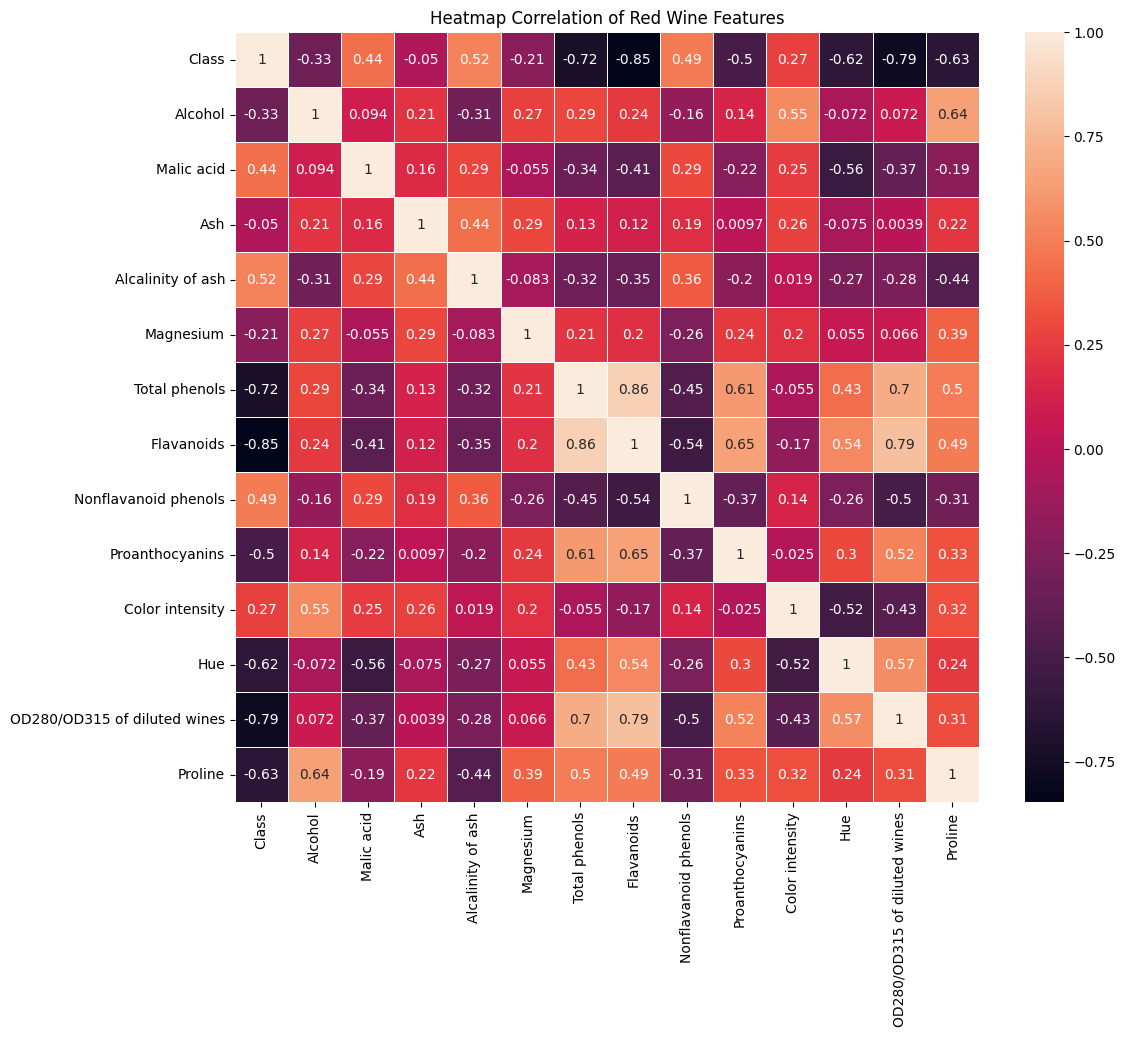

In [5]:
# drawing a heatmap to understand the correlation between every two of each of the 10 features

correlation_matrix = wine_df.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, linewidths=0.5)

#plotting heatmap
plt.title('Heatmap Correlation of Red Wine Features')
plt.show()

Training and Test Split data


In [6]:
X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)


In [7]:
supervised_ml_algorithms = {}
ml_algortihms = ['DT', 'NN', 'k-NN', 'SVM (linear)','SVM (sigmoid)', 'AdaBoost']

for algorithm in ml_algortihms:
    supervised_ml_algorithms[algorithm] = {}


# Decision Trees

Decision trees are a machine learning algorithm used in supervised learning. A tree can subcome to overfitting if too much noise is captured which would resulti in poor performance of the tree.
In order to prevent overfitting, maximum depth (`max_depth`) and cost-compexity pruning (`ccp_alpha`). `max-depth` and `ccp_alpha` are parametered set before the training process and are away to control overfitting.
A validation curve is created and helps us understand at what point the model maybe be overfitting or underfitting.
The best parameters are discovered from the `GridSearchCV` function and a confusion matrix illustrates the performance.
This tree is both pre-pruned and post-pruned, since it was pruned after the tree was created.
The methods of pruning illustrated are post-pruning. It was pre-pruned since contraints are created prior to training of the tree. It was also post-pruned adter the tree is fully contrusted.

The best tree found had a `ccp_alpha` value of 0, and a `max-depth` of 5, it has given a 92.13% accuracy score.

The learning curve concluded that there is room of improvement needed for the algorithm since there is a gap betweeen the training and validation score.

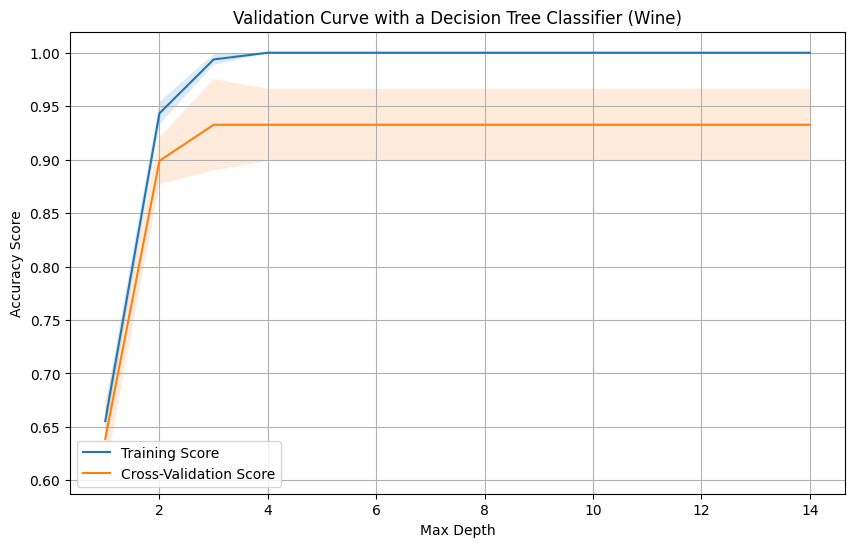

In [8]:
# Range of parameters we are looking into for our evaluation
param_range = np.arange(1, 15)

clf = tree.DecisionTreeClassifier(random_state=42)
#PRe-pruning the tree
train_scores, test_scores = validation_curve(clf, X_train_unscaled, y_train,param_name="max_depth",param_range=param_range, cv=5)


cv_mean_training = np.mean(train_scores, axis=1)
cv_std_training = np.std(train_scores, axis=1)
cv_mean_testing = np.mean(test_scores, axis=1)
cv_std_testing = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))

plt.plot(param_range, cv_mean_training, label="Training Score")
plt.fill_between(param_range, cv_mean_training - cv_std_training, cv_mean_training + cv_std_training, alpha=0.15)

plt.plot(param_range, cv_mean_testing, label="Cross-Validation Score")
plt.fill_between(param_range, cv_mean_testing - cv_std_testing, cv_mean_testing + cv_std_testing, alpha=0.15)

plt.title("Validation Curve with a Decision Tree Classifier (Wine)")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid()
plt.show()

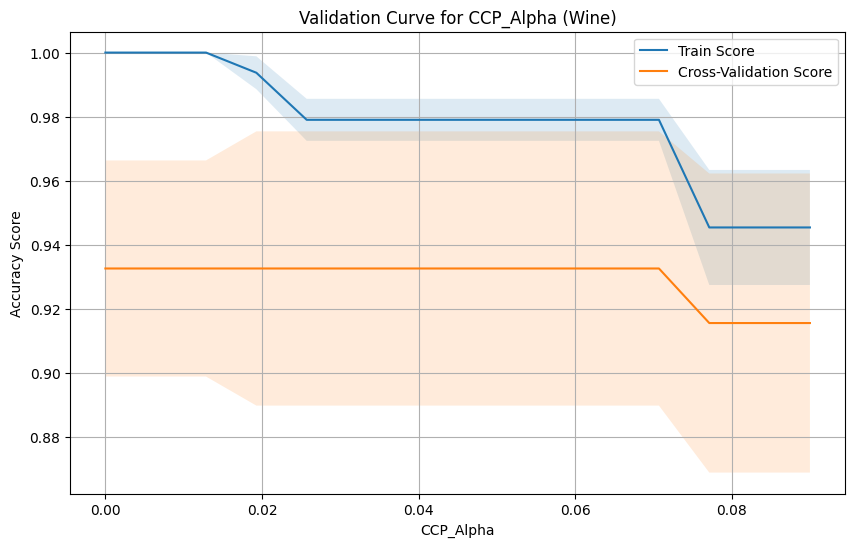

In [9]:

param_range_alpha = np.linspace(0, 0.09, 15)
#post pruning
train_scores, test_scores = validation_curve(clf, X_train_unscaled, y_train, param_range=param_range_alpha, param_name="ccp_alpha", cv=5)


ccp_mean_training = np.mean(train_scores, axis=1)
ccp_std_training = np.std(train_scores, axis=1)
ccp_mean_testing = np.mean(test_scores, axis=1)
ccp_std_testing = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))

plt.plot(param_range_alpha, ccp_mean_training, label="Train Score")
plt.fill_between(param_range_alpha, ccp_mean_training - ccp_std_training, ccp_mean_training + ccp_std_training, alpha=0.15)

plt.plot(param_range_alpha, ccp_mean_testing, label="Cross-Validation Score")
plt.fill_between(param_range_alpha, ccp_mean_testing - ccp_std_testing, ccp_mean_testing + ccp_std_testing, alpha=0.15)


plt.legend()

plt.title("Validation Curve for CCP_Alpha (Wine)")
plt.xlabel("CCP_Alpha")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()

In [10]:

param_grid = {'max_depth': param_range, 'ccp_alpha': param_range_alpha}

best_tree = GridSearchCV(clf, param_grid=param_grid, cv=5)

start_time = time.time()
best_tree.fit(X_train_unscaled, y_train)
end_time = time.time()

supervised_ml_algorithms['DT']['training_time'] = end_time-start_time


start_time = time.time()
accuracy_val = accuracy_score(y_test, best_tree.predict(X_test_unscaled))
supervised_ml_algorithms['DT']['accuracy'] = accuracy_val
end_time = time.time()
supervised_ml_algorithms['DT']['prediction_duration'] = end_time-start_time



print("Decision Tree")
print("Best params:",best_tree.best_params_)
print("Accuracy:", supervised_ml_algorithms['DT']['accuracy'])

Decision Tree
Best params: {'ccp_alpha': 0.0, 'max_depth': 4}
Accuracy: 0.9661016949152542


In [11]:
confusion_matrix = confusion_matrix(y_test, best_tree.predict(X_test_unscaled))
print(confusion_matrix)

[[19  1  0]
 [ 0 24  0]
 [ 1  0 14]]


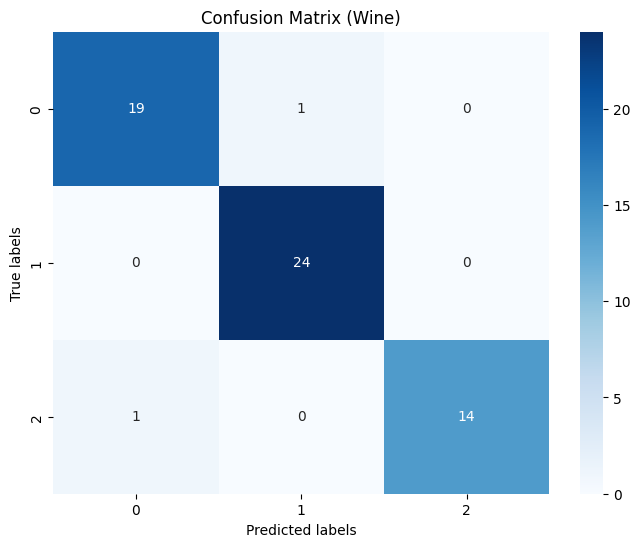

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues', cbar=True)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Wine)')
plt.show()


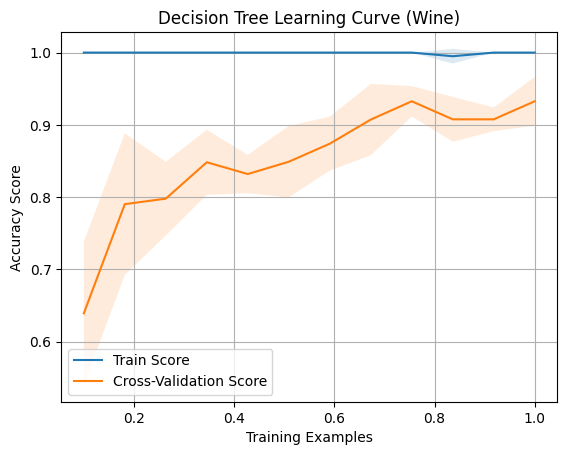

In [13]:
training_range=np.linspace(0.1, 1.0, 12)

clf = tree.DecisionTreeClassifier(random_state=42, max_depth=best_tree.best_params_['max_depth'], ccp_alpha=best_tree.best_params_['ccp_alpha'])
_, train_scores, test_scores = learning_curve(clf, X_train_unscaled, y_train, train_sizes=training_range, cv=5)


learning_mean_training = np.mean(train_scores, axis=1)
learning_std_training = np.std(train_scores, axis=1)
learning_mean_testing = np.mean(test_scores, axis=1)
learning_std_testing = np.std(test_scores, axis=1)


plt.figure()

plt.plot(training_range, np.mean(train_scores, axis=1), label='Train Score')
plt.fill_between(training_range, learning_mean_training - learning_std_training, learning_mean_training + learning_std_training, alpha=0.15)

plt.plot(training_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(training_range, learning_mean_testing - learning_std_testing, learning_mean_testing + learning_std_testing, alpha=0.15)


plt.legend()
plt.title("Decision Tree Learning Curve (Wine)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()


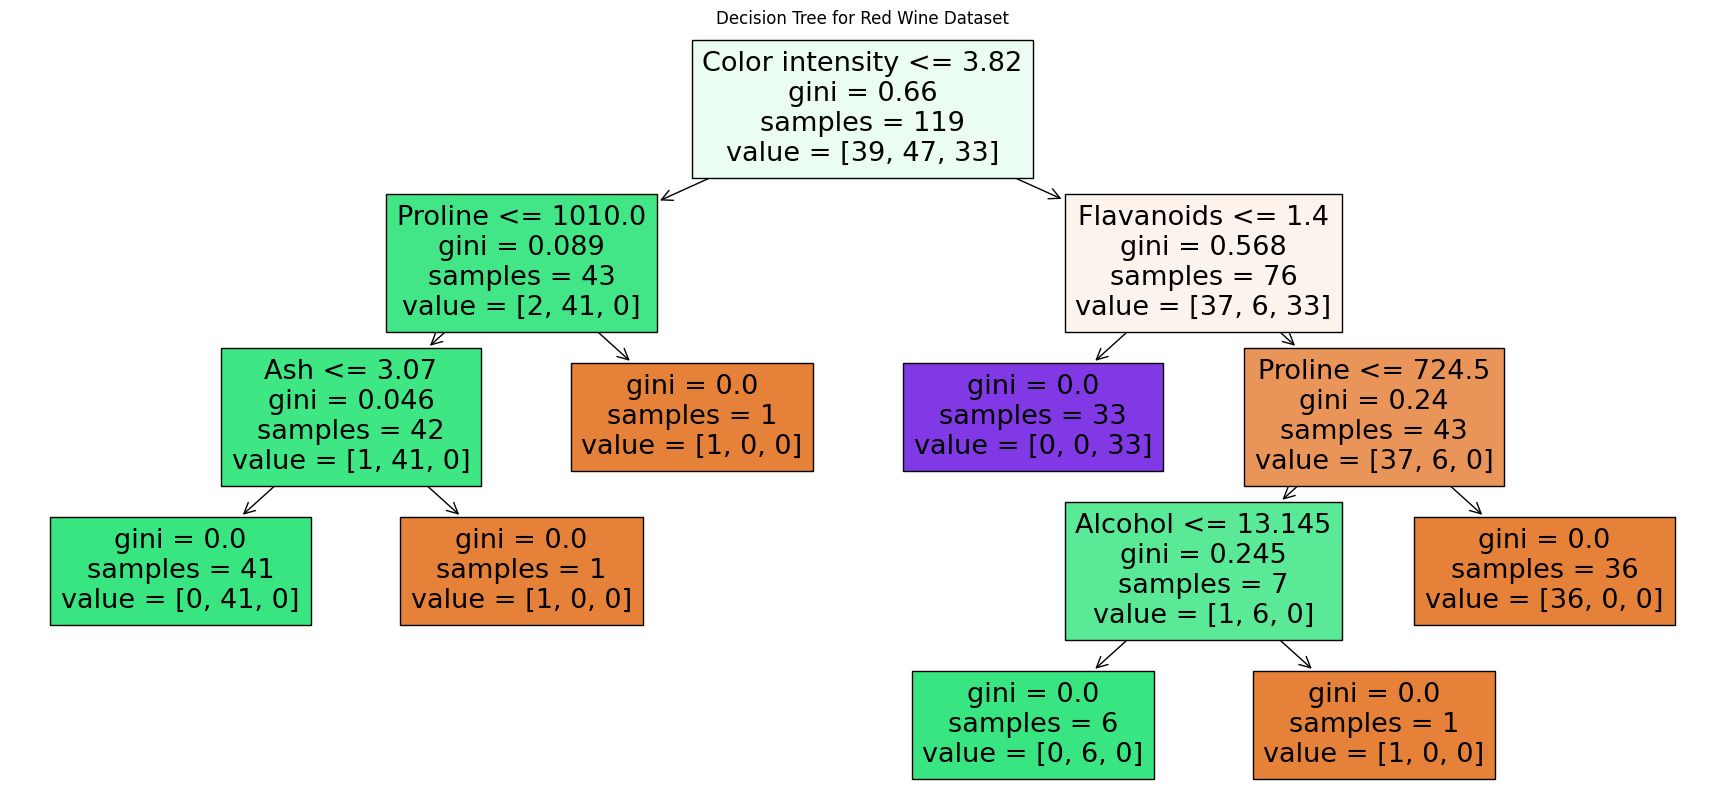

In [14]:
plt.figure(figsize=(22, 10))

plot_tree(best_tree.best_estimator_, filled=True, feature_names=wine_df.columns[1:])

plt.title("Decision Tree for Red Wine Dataset")

plt.show()

## Decision Trees - Training Trees at different pruning levels

In [15]:
# source https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html


path = clf.cost_complexity_pruning_path(X_train_unscaled, y_train)
ccp_alphas = path.ccp_alphas

total_alphas = ccp_alphas[:-1]


total_training_accurates = []
total_testing_accurates = []


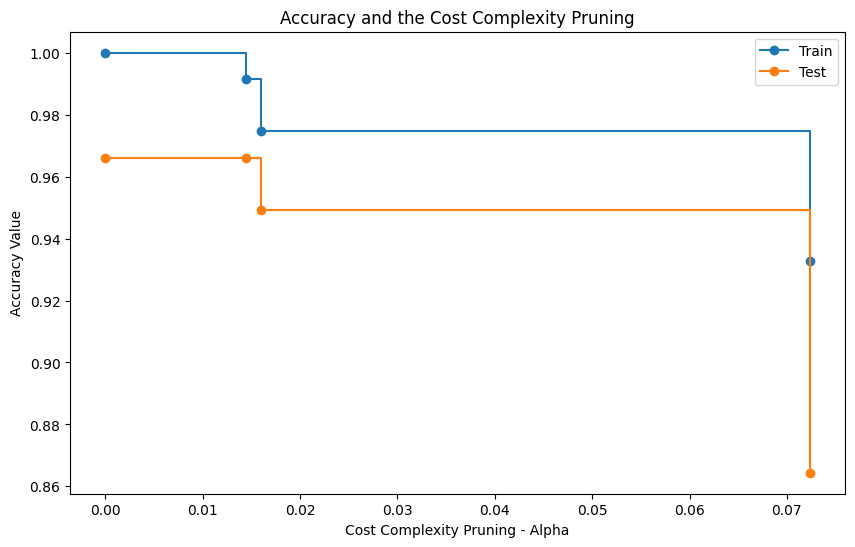

In [16]:
def plot_pruning(total_alphas):
  for ccp_alpha in total_alphas:


    clf = tree.DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train_unscaled, y_train)


    training_preds = clf.predict(X_train_unscaled)
    training_accuracy_score = accuracy_score(y_train, training_preds)
    total_training_accurates.append(training_accuracy_score)


    test_predictions = clf.predict(X_test_unscaled)
    testing_accuracy_score = accuracy_score(y_test, test_predictions)
    total_testing_accurates.append(testing_accuracy_score)

  # plotting the data
  plt.figure(figsize=(10, 6))

  plt.plot(total_alphas, total_training_accurates, marker='o', label="Train", drawstyle="steps-post")
  plt.plot(total_alphas, total_testing_accurates, marker='o', label="Test", drawstyle="steps-post")

  plt.xlabel("Cost Complexity Pruning - Alpha")
  plt.ylabel("Accuracy Value")
  plt.title("Accuracy and the Cost Complexity Pruning")

  plt.legend()
  plt.show()

plot_pruning(total_alphas)

# Boosting

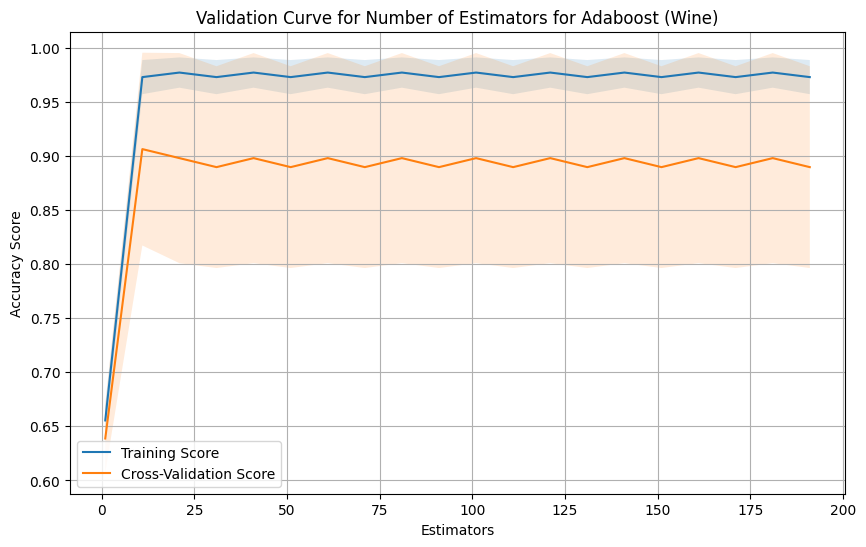

In [17]:
param_range = np.arange(1, 200, 10)

simple_tree = tree.DecisionTreeClassifier(max_depth=1, min_samples_leaf=1)
clf = AdaBoostClassifier(simple_tree, random_state=42)
train_scores, test_scores = validation_curve(clf, X_train_scaled, y_train, param_name="n_estimators", param_range=param_range, cv=5)


boosting_mean_training = np.mean(train_scores, axis=1)
boosting_std_training = np.std(train_scores, axis=1)
boosting_mean_testing = np.mean(test_scores, axis=1)
boosting_std_testing = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))

plt.plot(param_range, boosting_mean_training, label="Training Score")
plt.fill_between(param_range, boosting_mean_training - boosting_std_training, boosting_mean_training + boosting_std_training, alpha=0.15)

plt.plot(param_range, boosting_mean_testing, label="Cross-Validation Score")
plt.fill_between(param_range, boosting_mean_testing - boosting_std_testing, boosting_mean_testing + boosting_std_testing, alpha=0.15)

plt.legend()
plt.title("Validation Curve for Number of Estimators for Adaboost (Wine)")
plt.xlabel("Estimators")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()



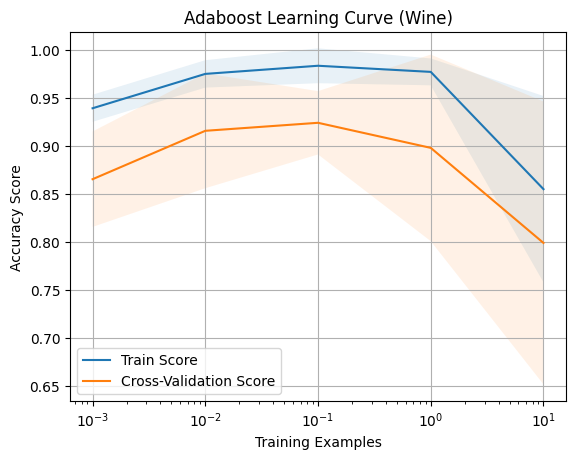

In [18]:
training_range=np.logspace(-3, 1, 5)
train_scores, test_scores = validation_curve(clf, X_train_scaled, y_train, param_name="learning_rate",param_range=training_range, cv=5)


learning_mean_training = np.mean(train_scores, axis=1)
learning_std_training = np.std(train_scores, axis=1)
learning_mean_testing = np.mean(test_scores, axis=1)
learning_std_testing = np.std(test_scores, axis=1)


plt.figure()

plt.semilogx(training_range, np.mean(train_scores, axis=1), label='Train Score')
plt.fill_between(training_range, learning_mean_training - learning_std_training, learning_mean_training + learning_std_training, alpha=0.1)

plt.semilogx(training_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(training_range, learning_mean_testing - learning_std_testing, learning_mean_testing + learning_std_testing, alpha=0.1)


plt.legend()
plt.title("Adaboost Learning Curve (Wine)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()


In [19]:
param_grid = {'learning_rate': [0.001, 0.01, 0.1, 1, 10], 'n_estimators': [0.001, 0.01, 0.1, 1, 10]}


best_boost = GridSearchCV(clf, param_grid=param_grid, cv=5)

start_time = time.time()
best_boost.fit(X_train_unscaled, y_train)
end_time = time.time()
supervised_ml_algorithms['AdaBoost']['training_time'] = end_time-start_time


best_ada_boost = best_boost.best_estimator_
start_time = time.time()
accuracy_score_val = accuracy_score(y_train, best_ada_boost.predict(X_train_unscaled))
supervised_ml_algorithms['AdaBoost']['accuracy'] = accuracy_score_val
end_time = time.time()
supervised_ml_algorithms['AdaBoost']['prediction_duration'] = end_time-start_time


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
75 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py", line 124, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/skl

In [20]:
print("Adaboost")
print("Best params:",best_boost.best_params_)
print("Accuracy:", supervised_ml_algorithms['AdaBoost']['accuracy'])

Adaboost
Best params: {'learning_rate': 0.1, 'n_estimators': 10}
Accuracy: 0.9243697478991597


In [21]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, best_boost.predict(X_test_scaled))
print(confusion_matrix)

[[ 0 20  0]
 [ 0 24  0]
 [ 0 15  0]]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


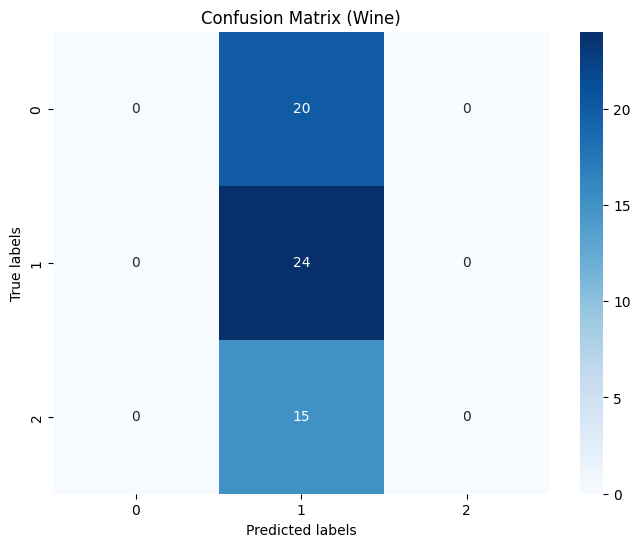

In [22]:

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues', cbar=True)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Wine)')
plt.show()

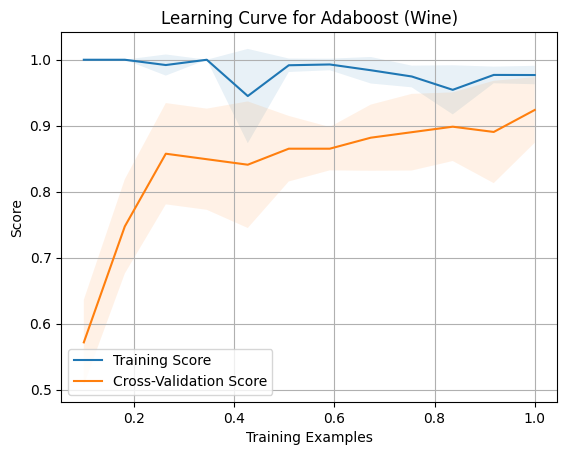

In [23]:
training_range=np.linspace(0.1, 1.0, 12)



tree_classifier = tree.DecisionTreeClassifier(random_state=42, max_depth=1,  min_samples_leaf=1)

clf = AdaBoostClassifier(tree_classifier, random_state=42, n_estimators=best_boost.best_params_['n_estimators'], learning_rate=best_boost.best_params_['learning_rate'])
_, train_scores, test_scores = learning_curve(clf, X_train_scaled, y_train, train_sizes=training_range, cv=5)


learning_mean_training = np.mean(train_scores, axis=1)
learning_std_training = np.std(train_scores, axis=1)
learning_mean_testing = np.mean(test_scores, axis=1)
learning_std_testing = np.std(test_scores, axis=1)


plt.figure()

plt.plot(training_range, np.mean(train_scores, axis=1), label='Training Score')
plt.fill_between(training_range, learning_mean_training - learning_std_training, learning_mean_training + learning_std_training, alpha=0.1)

plt.plot(training_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(training_range, learning_mean_testing - learning_std_testing, learning_mean_testing + learning_std_testing, alpha=0.1)

plt.legend()
plt.title("Learning Curve for Adaboost (Wine)")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.grid()
plt.show()

# Neural Networks

A neural network
The neural network implemented in the code for our datasets consists of two hidden layers, with both layers containing 4 nodes.

To start we will follow the same process we did with the decision tree.
The two parameters we will focus on when it comes to optimization are the learning rate and the regularization parameter, which will be called as alpha.

The loss and accuracy curve are added to illustrate characteristics of model performance over epochs.

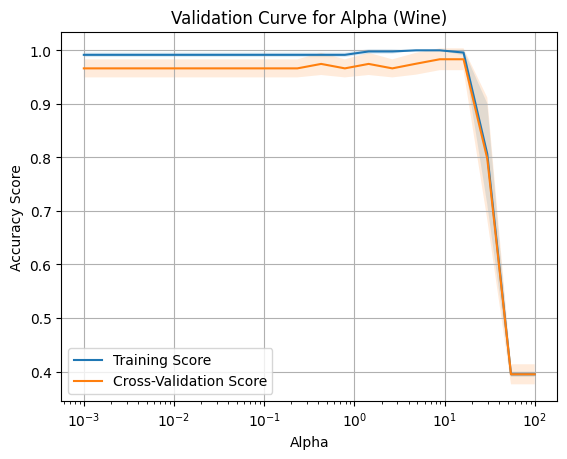

In [24]:
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

param_range = np.logspace(-3, 2, 20)


clf = MLPClassifier( random_state=42, max_iter=1500, hidden_layer_sizes=(4, 4))
train_scores, test_scores = validation_curve(clf, X_train_scaled, y_train, param_name="alpha", param_range=param_range, cv=5)

vc_mean_training = np.mean(train_scores, axis=1)
vc_std_training = np.std(train_scores, axis=1)
vc_mean_testing = np.mean(test_scores, axis=1)
vc_std_testing = np.std(test_scores, axis=1)


plt.figure()

plt.semilogx(param_range, np.mean(train_scores, axis=1), label="Training Score")
plt.fill_between(param_range, vc_mean_training -vc_std_training, vc_mean_training + vc_std_training, alpha=0.15)

plt.semilogx(param_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(param_range, vc_mean_testing - vc_std_testing, vc_mean_testing + vc_std_testing, alpha=0.15)

plt.legend()
plt.title("Validation Curve for Alpha (Wine)")
plt.xlabel("Alpha")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()



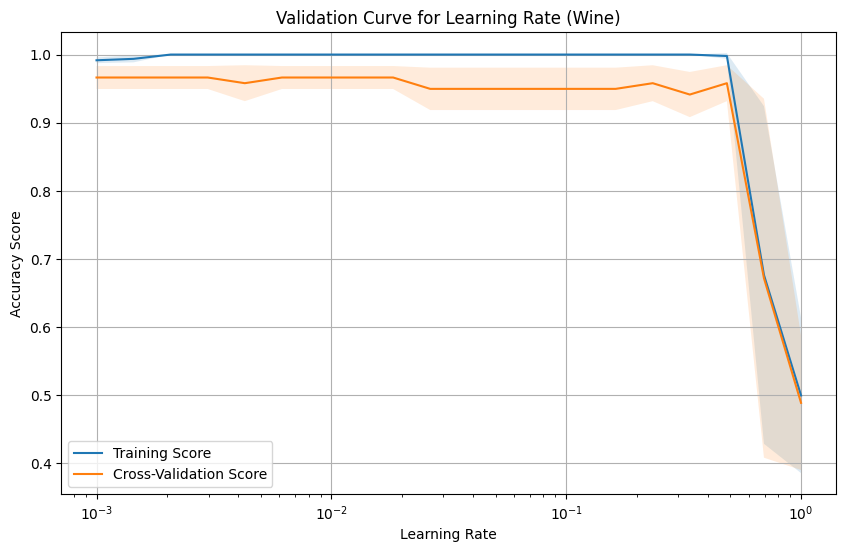

In [25]:
param_range_learning = np.logspace(-3, 0, 20)

train_scores, test_scores = validation_curve(clf, X_train_scaled, y_train, param_name="learning_rate_init", param_range=param_range_learning, cv=5)

cv_mean_training = np.mean(train_scores, axis=1)
cv_std_training = np.std(train_scores, axis=1)
cv_mean_testing = np.mean(test_scores, axis=1)
cv_std_testing = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))

plt.semilogx(param_range_learning, cv_mean_training, label="Training Score")
plt.fill_between(param_range_learning, cv_mean_training - cv_std_training, cv_mean_training + cv_std_training, alpha=0.15)

plt.semilogx(param_range_learning, cv_mean_testing, label="Cross-Validation Score")
plt.fill_between(param_range_learning, cv_mean_testing - cv_std_testing, cv_mean_testing + cv_std_testing, alpha=0.15)


plt.legend()
plt.title("Validation Curve for Learning Rate (Wine)")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()


In [26]:
param_grid = {
    'alpha': param_range,
    'learning_rate_init': param_range_learning
}

best_nn = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy')



start_time = time.time()
best_nn.fit(X_train_scaled, y_train)
end_time = time.time()

supervised_ml_algorithms['NN']['training_time'] = end_time-start_time


start_time = time.time()
accuracy_score_val = accuracy_score(y_test, best_nn.predict(X_test_scaled))
supervised_ml_algorithms['NN']['accuracy'] = accuracy_score_val

end_time = time.time()
supervised_ml_algorithms['NN']['prediction_duration'] = end_time-start_time


print("Neural Network")
print("Best params:",best_nn.best_params_)
print("Accuracy:", supervised_ml_algorithms['NN']['accuracy'])

Neural Network
Best params: {'alpha': 1.438449888287663, 'learning_rate_init': 0.07847599703514611}
Accuracy: 0.9830508474576272


In [27]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, best_nn.predict(X_test_scaled))
print(confusion_matrix)

[[20  0  0]
 [ 0 23  1]
 [ 0  0 15]]


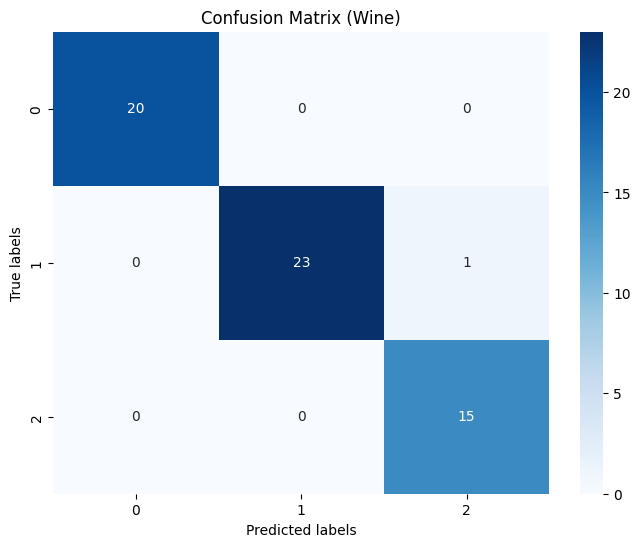

In [28]:
# Plot confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues', cbar=True)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Wine)')
plt.show()

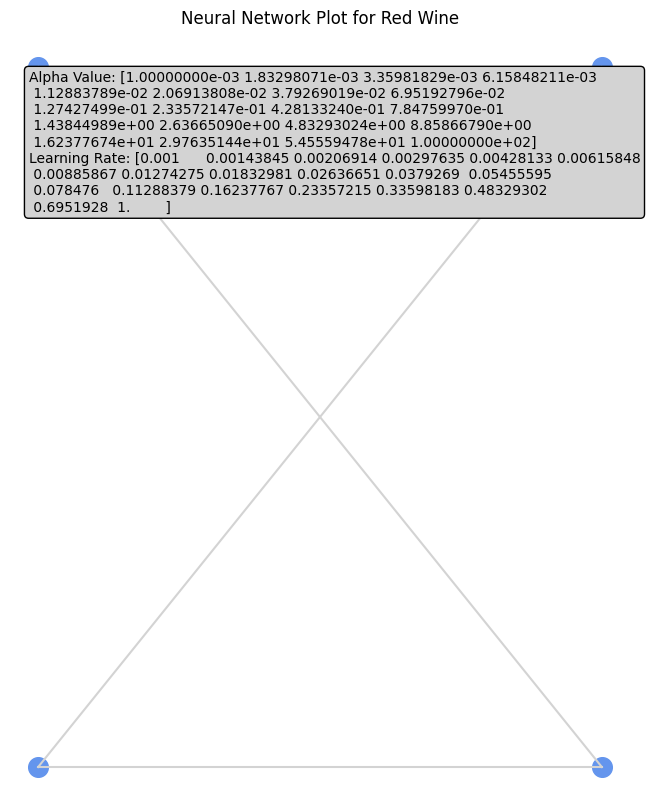

In [29]:
def plot_neural_network(neural_layer, alpha, learning_rate_init):

  neural_layer_size = len(neural_layer) -1

  fig, ax = plt.subplots(figsize=(8, 10))

  num = 2

  for index, layer_size in enumerate(neural_layer):

    for layer_index in range(layer_size):

      x = index * num
      y = layer_index  - (layer_size - 1) * 1 / 2

      # plots neuron
      ax.scatter(x, y, s=200, c='cornflowerblue', zorder=neural_layer_size)

      # plots synapses
      if index < neural_layer_size:
        next_size = neural_layer[index + 1]

        for layer_index in range(next_size):
          next_y = layer_index - (next_size - 1) * 1 / 2
          ax.plot([x, x + num], [y, next_y], c='lightgrey')

  ax.text(0.03, 0.95, f"Alpha Value: {alpha}\nLearning Rate: {learning_rate_init}", transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgrey'))
  ax.axis('off')
  plt.title('Neural Network Plot for Red Wine')
  plt.show()

plot_neural_network([2,2], param_range, param_range_learning)

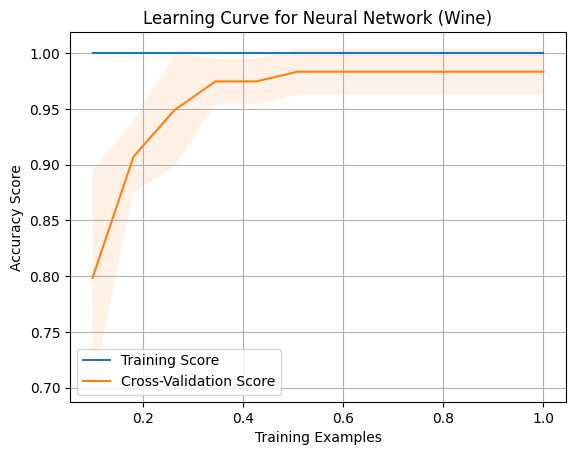

In [30]:
training_range=np.linspace(0.1, 1.0, 12)


clf = MLPClassifier(hidden_layer_sizes=(4, 4), random_state=42, max_iter=500, learning_rate_init=best_nn.best_params_['learning_rate_init'], alpha=best_nn.best_params_['alpha'])
_, train_scores, test_scores = learning_curve(clf, X_train_scaled, y_train, train_sizes=training_range, cv=5)


learning_mean_training = np.mean(train_scores, axis=1)
learning_std_training = np.std(train_scores, axis=1)
learning_mean_testing = np.mean(test_scores, axis=1)
learning_std_testing = np.std(test_scores, axis=1)


plt.figure()

plt.plot(training_range, np.mean(train_scores, axis=1), label='Training Score')
plt.fill_between(training_range, learning_mean_training - learning_std_training, learning_mean_training + learning_std_training, alpha=0.1)

plt.plot(training_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(training_range, learning_mean_testing - learning_std_testing, learning_mean_testing + learning_std_testing, alpha=0.1)

plt.legend()
plt.title("Learning Curve for Neural Network (Wine)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()



In [31]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse=False)
X_training, X_validate, y_training, y_validate = train_test_split(X_train_scaled, y_train, test_size=0.33, random_state=42)

y_training_encoded = enc.fit_transform(y_training.values.reshape(-1, 1))
y_validate_encoded = enc.transform(y_validate.values.reshape(-1, 1))

clf = MLPClassifier( random_state=42, max_iter=1, alpha=best_nn.best_params_['alpha'], learning_rate_init=best_nn.best_params_['learning_rate_init'], warm_start=True)

epochs = 150
train_loss_curve_values = []
train_score_curve_values = []
val_score_curve_values = []


# Training a nueral network over multiple epochs
for epoch in range(epochs):
    clf.fit(X_training, y_training)


    train_loss_curve_values.append(clf.loss_)
    train_predictions = clf.predict(X_training)
    train_accuracy = (train_predictions == y_training.values).mean()
    train_score_curve_values.append(train_accuracy)


    val_predictions = clf.predict(X_training)
    val_accuracy = np.mean(val_predictions == y_validate.values)
    print(val_accuracy)
    val_score_curve_values.append(val_accuracy)




/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the futu

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWar

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  val_accuracy = np.mean(val_predictions == y_validate.values)
<ipython-input-31-e9eef398e830>:29: DeprecationWar

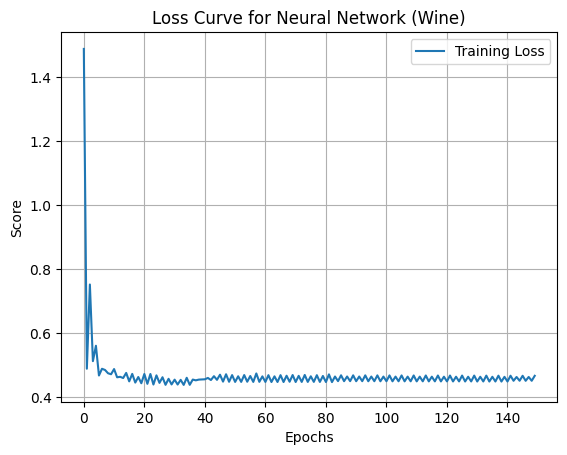

In [32]:
plt.figure()

plt.plot(train_loss_curve_values, label='Training Loss')


plt.legend()
plt.title("Loss Curve for Neural Network (Wine)")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.grid()
plt.show()


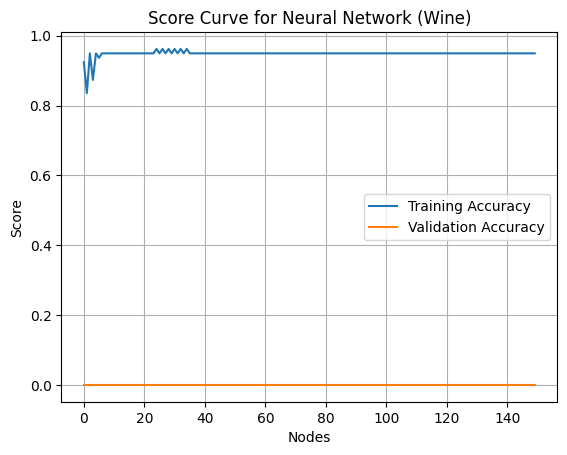

In [33]:
plt.figure()

plt.plot(train_score_curve_values, label='Training Accuracy')
plt.plot(val_score_curve_values, label='Validation Accuracy')


plt.legend()
plt.title("Score Curve for Neural Network (Wine)")
plt.xlabel("Nodes")
plt.ylabel("Score")
plt.grid()
plt.show()


# K-Nearest Neighbor


Streaming output truncated to the last 5000 lines.

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 234, in __call__
    return self._score(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 276, in _score
    y_pred = method_caller(estimator, "predict", X)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 73, in _cached_call
    return getattr(estimator, method)(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py", line 234, in predict


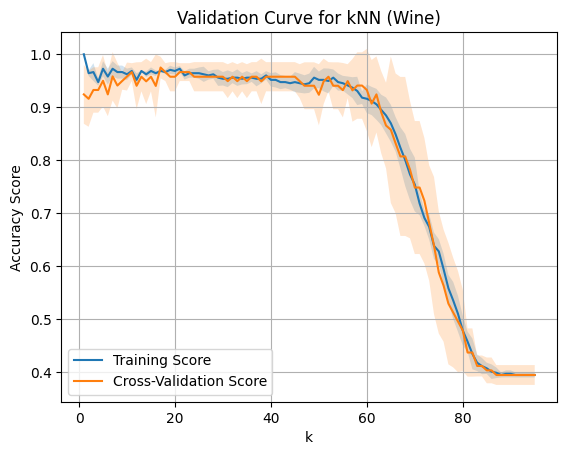

In [34]:
param_range = list(range(1, 180))
neigh = KNeighborsClassifier()
train_scores, test_scores = validation_curve(neigh, X_train_scaled, y_train, param_range=param_range, param_name='n_neighbors', scoring="accuracy", cv=5)

vc_mean_training = np.mean(train_scores, axis=1)
vc_std_training = np.std(train_scores, axis=1)
vc_mean_testing = np.mean(test_scores, axis=1)
vc_std_testing = np.std(test_scores, axis=1)


plt.figure()

plt.plot(param_range, np.mean(train_scores, axis=1), label="Training Score")
plt.fill_between(param_range, vc_mean_training -vc_std_training, vc_mean_training + vc_std_training, alpha=0.2)

plt.plot(param_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(param_range, vc_mean_testing - vc_std_testing, vc_mean_testing + vc_std_testing, alpha=0.2)

plt.legend()
plt.title("Validation Curve for kNN (Wine)")
plt.xlabel("k")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()


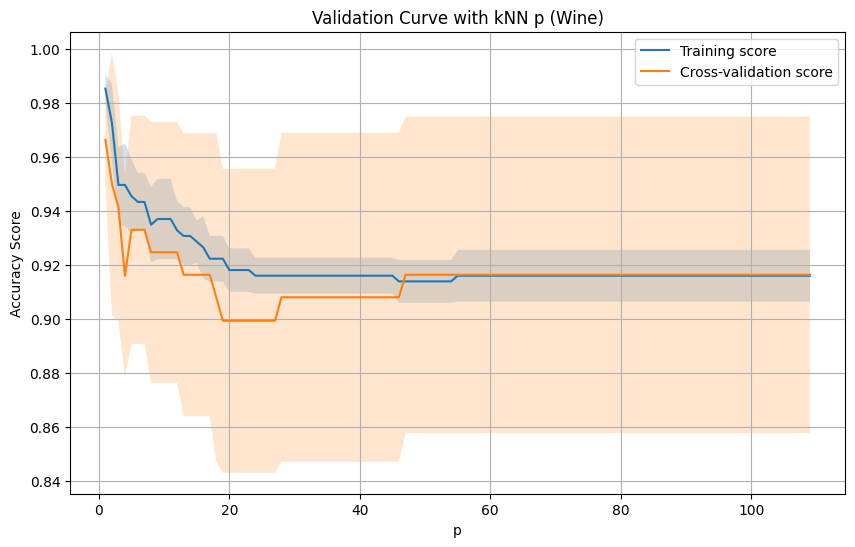

In [35]:

param_range_distance = list(range(1, 110))
train_scores, test_scores = validation_curve(neigh, X_train_scaled, y_train, param_name="p", param_range=param_range_distance, cv=5)

vc_mean_training = np.mean(train_scores, axis=1)
vc_std_training = np.std(train_scores, axis=1)
vc_mean_testing = np.mean(test_scores, axis=1)
vc_std_testing = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))

plt.plot(param_range_distance, vc_mean_training, label="Training score")
plt.plot(param_range_distance, vc_mean_testing, label="Cross-validation score")

plt.fill_between(param_range_distance, vc_mean_training - vc_std_training, vc_mean_training + vc_std_training, alpha=0.2)
plt.fill_between(param_range_distance, vc_mean_testing - vc_std_testing, vc_mean_testing + vc_std_testing, alpha=0.2)

plt.title("Validation Curve with kNN p (Wine)")
plt.xlabel("p")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid()
plt.show()


In [36]:


param_grid = {'n_neighbors': param_range, 'p':param_range_distance}
best_knn = GridSearchCV(neigh, param_grid=param_grid, cv=4)




start_time = time.time()
best_knn.fit(X_train_scaled, y_train)
end_time = time.time()

supervised_ml_algorithms['k-NN']['training_time'] = end_time-start_time




start_time = time.time()
accuracy_score_val = accuracy_score(y_test, best_knn.predict(X_test_scaled))
supervised_ml_algorithms['k-NN']['accuracy'] = accuracy_score_val
end_time = time.time()
supervised_ml_algorithms['k-NN']['prediction_duration'] = end_time-start_time



print("K-NN")
print("Best params:",best_knn.best_params_)
print("Accuracy:", supervised_ml_algorithms['k-NN']['accuracy'])

Streaming output truncated to the last 5000 lines.
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_base.py", line 810, in kneighbors
    raise ValueError(
ValueError: Expected n_neighbors <= n_samples,  but n_samples = 89, n_neighbors = 179

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 444, in _passthrough_scorer
    return estimator.score(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 668, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
  File "/usr/l

K-NN
Best params: {'n_neighbors': 43, 'p': 1}
Accuracy: 0.9661016949152542


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [0.96609195 0.92442529 0.90747126 ...        nan        nan        nan]
  warnings.warn(


In [37]:
from sklearn.metrics import confusion_matrix


confusion_matrix = confusion_matrix(y_test, best_knn.predict(X_test_scaled))

print(confusion_matrix)

[[20  0  0]
 [ 2 22  0]
 [ 0  0 15]]


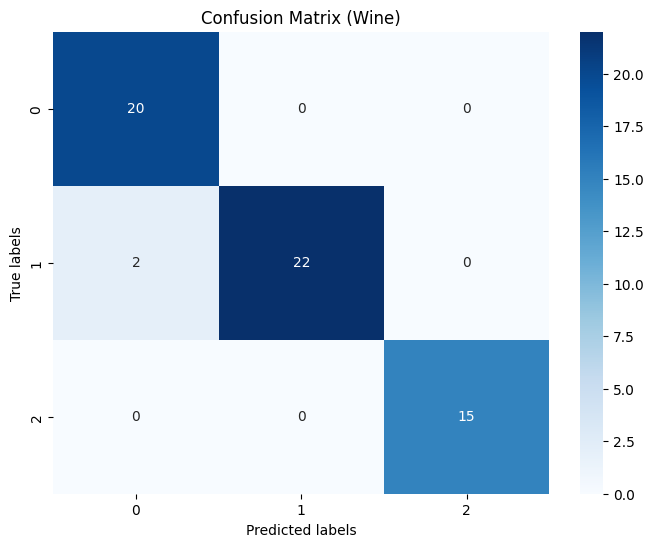

In [38]:
# Plot confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues', cbar=True)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Wine)')
plt.show()

In [39]:

learning_range = np.linspace(0.1,1.0,10)

learning_knn = KNeighborsClassifier(n_neighbors=best_knn.best_params_['n_neighbors'], p=best_knn.best_params_['p'])
_, train_scores, test_scores = learning_curve(learning_knn, X_train_scaled, y_train, train_sizes=learning_range, cv=5)



learning_mean_training = np.mean(train_scores, axis=1)
learning_std_training = np.std(train_scores, axis=1)
learning_mean_testing = np.mean(test_scores, axis=1)
learning_std_testing = np.std(test_scores, axis=1)




/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 444, in _passthrough_scorer
    return estimator.score(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 668, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py", line 234, in predict
    neigh_ind = self.kneighbors(X, return_distance=False)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_base.py", line 810, in kneighbors
    raise ValueError(
Val

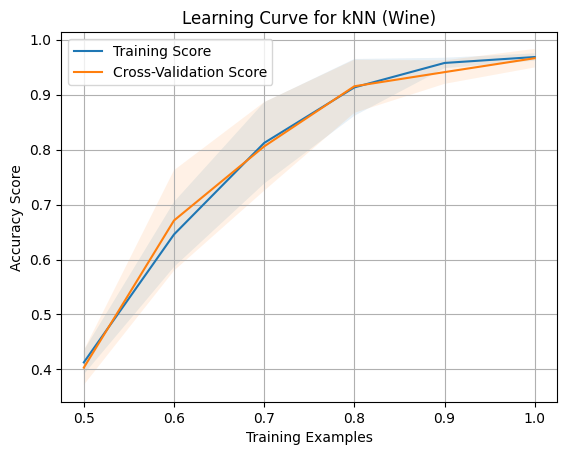

In [40]:
plt.figure()

plt.plot(learning_range, np.mean(train_scores, axis=1), label='Training Score')
plt.fill_between(learning_range, learning_mean_training - learning_std_training, learning_mean_training + learning_std_training, alpha=0.1)

plt.plot(learning_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(learning_range, learning_mean_testing - learning_std_testing, learning_mean_testing + learning_std_testing, alpha=0.1)


plt.legend()
plt.title("Learning Curve for kNN (Wine)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()

## Implementation

In [41]:
X = wine_df.iloc[:, 1:]
y = wine_df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [42]:
def evaluate_knn(k_values):
    accuracies = []
    for k in k_values:

        knn = KNeighborsClassifier(n_neighbors=k)

        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

    return accuracies

k_values = list(range(1, 120))
accuracies = evaluate_knn(k_values)

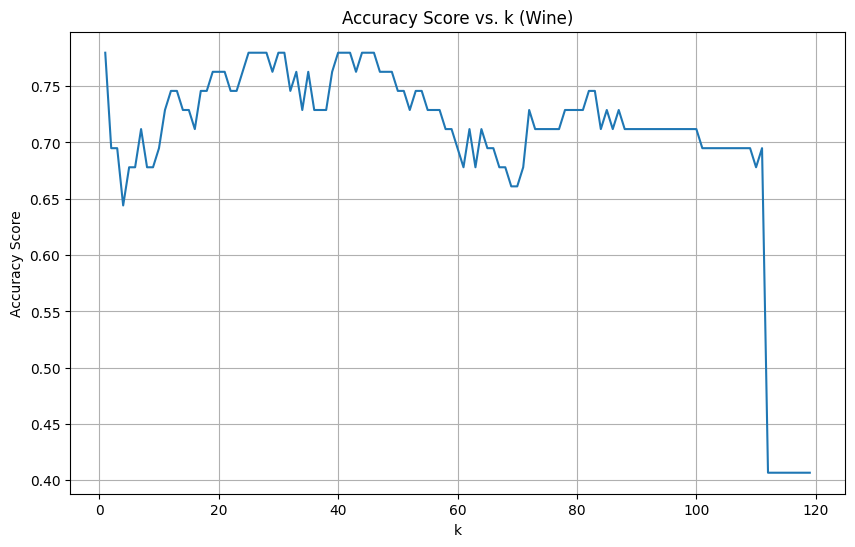

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, linestyle='-')
plt.title('Accuracy Score vs. k (Wine)')
plt.xlabel('k')
plt.ylabel('Accuracy Score')
plt.grid()
plt.show()


# Support Vector Machine

In [85]:
SX_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)

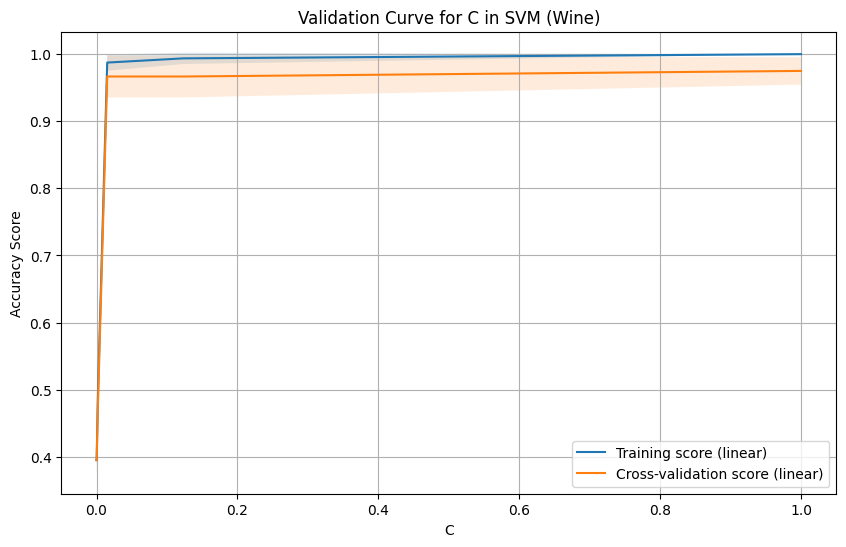

In [86]:
param_range = np.logspace(-10, 0, 12)

kernel_type_list= ['linear', 'rbf', 'poly', 'sigmoid']

svc_clf = SVC(kernel='linear', random_state=42)
train_scores, test_scores = validation_curve(svc_clf, X_train_scaled, y_train, param_name="C", param_range = param_range, cv=5)

vc_mean_training = np.mean(train_scores, axis=1)
vc_std_training = np.std(train_scores, axis=1)
vc_mean_testing = np.mean(test_scores, axis=1)
vc_std_testing = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))

plt.plot(param_range, vc_mean_training, label="Training score (linear)")
plt.plot(param_range, vc_mean_testing, label="Cross-validation score (linear)")

plt.fill_between(param_range, vc_mean_training - vc_std_training, vc_mean_training + vc_std_training, alpha=0.15)
plt.fill_between(param_range, vc_mean_testing - vc_std_testing, vc_mean_testing + vc_std_testing, alpha=0.15)


plt.title("Validation Curve for C in SVM (Wine)")
plt.xlabel("C")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid()
plt.show()

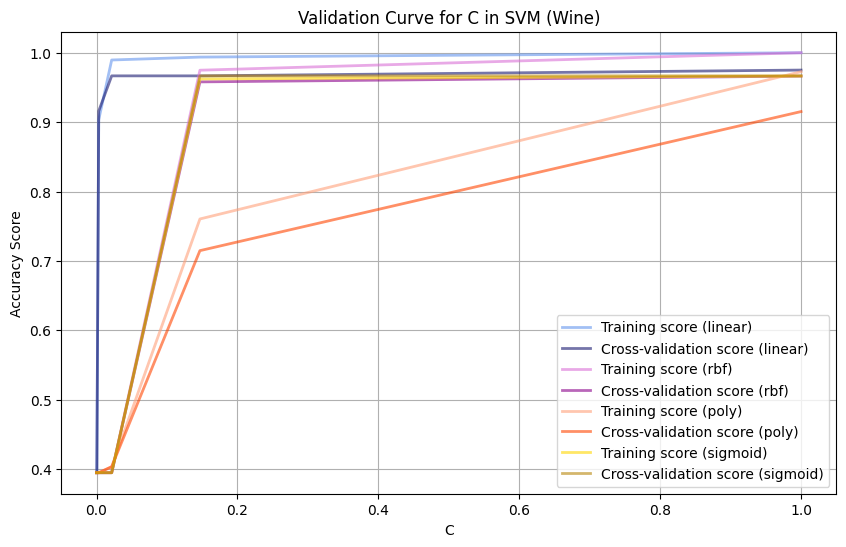

In [87]:
param_range = np.logspace(-10, 0, 13)

kernel_type_list= ['linear', 'rbf', 'poly', 'sigmoid']

training_colors = ['cornflowerblue', 'orchid', 'lightsalmon', 'gold']
cross_validation_colors = ['midnightblue', 'darkmagenta', 'orangered', 'darkgoldenrod']

color_counter = 0

plt.figure(figsize=(10, 6))

for kernel in kernel_type_list:

  training_label = "Training score ({kernel})"
  cross_validation_label = "Cross-validation score ({kernel})"

  svc_clf = SVC(kernel=kernel, random_state=42)
  train_scores, test_scores = validation_curve(svc_clf, X_train_scaled, y_train, param_name="C", param_range = param_range, cv=5)

  vc_mean_training = np.mean(train_scores, axis=1)
  vc_std_training = np.std(train_scores, axis=1)
  vc_mean_testing = np.mean(test_scores, axis=1)
  vc_std_testing = np.std(test_scores, axis=1)


  plt.plot(param_range, vc_mean_training, linewidth=2, label=training_label.format(kernel=kernel), color = training_colors[color_counter], alpha=0.60)
  plt.plot(param_range, vc_mean_testing, linewidth=2, label=cross_validation_label.format(kernel=kernel), color = cross_validation_colors[color_counter], alpha=0.60)

  #plt.fill_between(param_range, vc_mean_training - vc_std_training, vc_mean_training + vc_std_training, alpha=0.15, color = training_colors[color_counter])
  #plt.fill_between(param_range, vc_mean_testing - vc_std_testing, vc_mean_testing + vc_std_testing, alpha=0.15, color = cross_validation_colors[color_counter])

  color_counter += 1


plt.title("Validation Curve for C in SVM (Wine)")
plt.xlabel("C")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid()
plt.show()

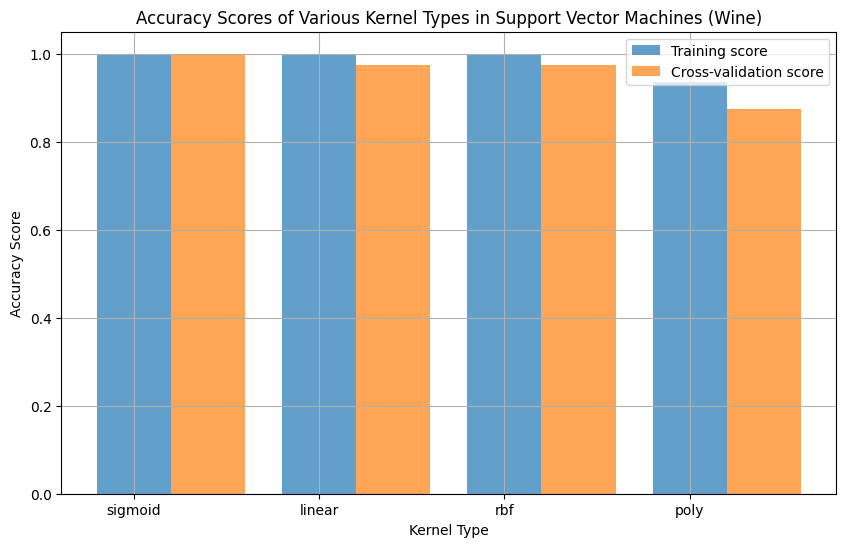

In [94]:
X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(X_train_scaled, y_train, test_size=0.33, random_state=42)

param_range = np.arange(0,10)


train_scores = np.zeros((4,1))
test_scores = np.zeros((4,1))


kernel_type_list= ['sigmoid','linear', 'rbf', 'poly', ]

for i, kernel_type in enumerate(kernel_type_list):
    svc_clf = SVC(kernel=kernel_type, random_state=42, )
    svc_clf.fit(X_train_train, y_train_train)
    train_scores[i] = accuracy_score(y_train_train, svc_clf.predict(X_train_train))
    test_scores[i] = accuracy_score(y_train_val, svc_clf.predict(X_train_val))

bar_positions = np.arange(len(kernel_type_list))

bar_width = .4

vc_kernel_mean_training = np.mean(train_scores, axis=1)
vc_kernel_std_training = np.std(train_scores, axis=1)
vc_kernel_mean_testing = np.mean(test_scores, axis=1)
vc_kernel_std_testing = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))

plt.bar(bar_positions, vc_kernel_mean_training, label="Training score", width=bar_width, alpha = .70)
plt.bar(bar_positions + bar_width, vc_kernel_mean_testing, label="Cross-validation score", width=bar_width, alpha = .70)


plt.legend()
plt.title("Accuracy Scores of Various Kernel Types in Support Vector Machines (Wine)")
plt.xlabel("Kernel Type")
plt.ylabel("Accuracy Score")
plt.xticks(np.arange(4),['sigmoid','linear','rbf','poly'])
plt.grid()
plt.show()

In [48]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': kernel_type_list,
}
best_svm = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring="accuracy", n_jobs=-1)

start_time = time.time()
best_svm.fit(X_train_train, y_train_train)
end_time = time.time()
supervised_ml_algorithms['SVM (sigmoid)']['training_time'] = end_time-start_time


best = best_svm.best_estimator_
start_time = time.time()
accuracy_score_val = accuracy_score(y_train_val, best.predict(X_train_val))
supervised_ml_algorithms['SVM (sigmoid)']['accuracy'] = accuracy_score_val
end_time = time.time()
supervised_ml_algorithms['SVM (sigmoid)']['prediction_duration'] = end_time-start_time


print("SVM")
print("Best params:",best_svm.best_params_)
print("Accuracy:", supervised_ml_algorithms['SVM (sigmoid)']['training_time'])

SVM
Best params: {'C': 0.1, 'kernel': 'sigmoid'}
Accuracy: 1.435417890548706


In [49]:
from sklearn.metrics import confusion_matrix


#confusion_matrix(y_test, best_svm.predict(X_train_unscaled))

#print(confusion_matrix)

In [50]:
# Plot confusion matrix

#plt.figure(figsize=(8, 6))
#sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues', cbar=True)
#plt.xlabel('Predicted labels')
#plt.ylabel('True labels')
#plt.title('Confusion Matrix (Wine)')
#plt.show()

sigmoid


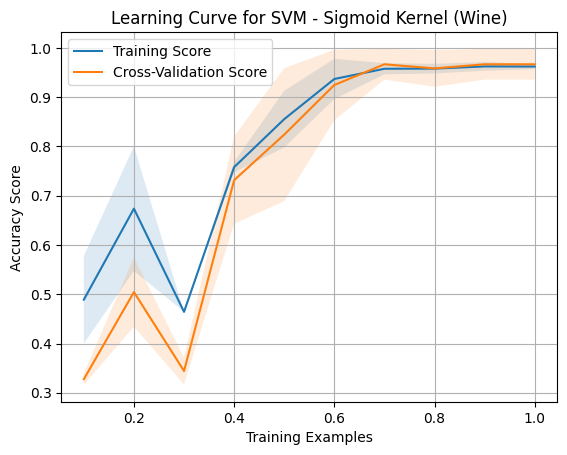

In [51]:
param_range = np.linspace(0.1,1.0,10)

print(best_svm.best_params_['kernel'])
clf_svm = SVC(random_state=42, C=best_svm.best_params_['C'], kernel=best_svm.best_params_['kernel'])
_, train_scores, test_scores = learning_curve(clf_svm, X_train_scaled, y_train, train_sizes= param_range, cv=5)

learning_mean_training = np.mean(train_scores, axis=1)
learning_std_training = np.std(train_scores, axis=1)
learning_mean_testing = np.mean(test_scores, axis=1)
learning_std_testing = np.std(test_scores, axis=1)


plt.figure()


plt.plot(param_range, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(param_range, np.mean(test_scores, axis=1), label='Cross-Validation Score')



plt.fill_between(param_range, learning_mean_training - learning_std_training, learning_mean_training + learning_std_training, alpha=0.15)
plt.fill_between(param_range, learning_mean_testing - learning_std_testing, learning_mean_testing + learning_std_testing, alpha=0.15)


plt.legend()
plt.title("Learning Curve for SVM - Sigmoid Kernel (Wine)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.show()


## Displaying SVM with Sigmoid Kernel

In [52]:
current_kernel = best_svm.best_params_['kernel']
c_value = best_svm.best_params_['C']

In [53]:

X_scaled = scaler.fit_transform(X)

X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

svm_classifier = SVC(kernel=current_kernel, C=c_value, random_state=42)
svm_classifier.fit(X_train_plot, y_train_plot)

accuracy = svm_classifier.score(X_test_plot, y_test_plot)



In [54]:
X = wine_df.iloc[:, [1, 2]].values
y = wine_df.iloc[:, 0].values

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.3, random_state=42)

X_train[:5], y_train[:5]

svm_clf = SVC(kernel=current_kernel, C=1.0, random_state=42)
svm_clf.fit(X_train, y_train)

accuracy = svm_clf.score(X_test, y_test)

## Implementing a learning curve for a different kernel

In [56]:
X = wine_df.drop("Class", axis=1)
y = wine_df["Class"]


X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)


In [57]:
print(kernel_type_list)
best_kernel = best_svm.best_params_['kernel']
if best_kernel in kernel_type_list:
  kernel_type_list.remove(best_kernel)

['linear', 'rbf', 'poly', 'sigmoid']


In [58]:


param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': kernel_type_list,
}

print(best_svm.best_params_['kernel'])


best_svm = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring="accuracy", n_jobs=-1)

start_time = time.time()
best_svm.fit(X_train_train, y_train_train)
end_time = time.time()
supervised_ml_algorithms['SVM (linear)']['training_time'] = end_time-start_time


best = best_svm.best_estimator_
start_time = time.time()
accuracy_score_val = accuracy_score(y_train_val, best.predict(X_train_val))
supervised_ml_algorithms['SVM (linear)']['accuracy'] = accuracy_score_val

end_time = time.time()
supervised_ml_algorithms['SVM (linear)']['prediction_duration'] = end_time-start_time



print("SVM")
print("Best params:",best_svm.best_params_)
print("Accuracy:", supervised_ml_algorithms['SVM (linear)']['training_time'])

sigmoid
SVM
Best params: {'C': 1, 'kernel': 'linear'}
Accuracy: 0.16114425659179688


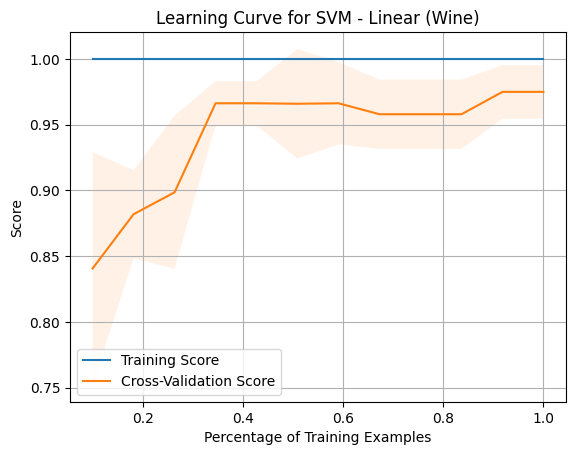

In [59]:

training_range=np.linspace(0.1, 1.0, 12)


clf = SVC(random_state=42, C=best_svm.best_params_['C'], kernel=best_svm.best_params_['kernel'])
_, train_scores, test_scores = learning_curve(clf, X_train_scaled, y_train, train_sizes=training_range, cv=5)


learning_mean_training = np.mean(train_scores, axis=1)
learning_std_training = np.std(train_scores, axis=1)
learning_mean_testing = np.mean(test_scores, axis=1)
learning_std_testing = np.std(test_scores, axis=1)


plt.figure()

plt.plot(training_range, np.mean(train_scores, axis=1), label='Training Score')
plt.fill_between(training_range, learning_mean_training - learning_std_training, learning_mean_training + learning_std_training, alpha=0.1)

plt.plot(training_range, np.mean(test_scores, axis=1), label="Cross-Validation Score")
plt.fill_between(training_range, learning_mean_testing - learning_std_testing, learning_mean_testing + learning_std_testing, alpha=0.1)

plt.legend()
plt.title("Learning Curve for SVM - Linear (Wine)")
plt.xlabel("Percentage of Training Examples")
plt.ylabel("Score")
plt.grid()
plt.show()


# Supervise Machine Learning Overview

In [63]:
print(supervised_ml_algorithms)

{'DT': {'training_time': 8.225761413574219, 'accuracy': 0.9661016949152542, 'prediction_duration': 0.002223491668701172}, 'NN': {'training_time': 150.53684520721436, 'accuracy': 0.9830508474576272, 'prediction_duration': 0.0008931159973144531}, 'k-NN': {'training_time': 255.8063178062439, 'accuracy': 0.9661016949152542, 'prediction_duration': 0.0051310062408447266}, 'SVM (linear)': {'training_time': 0.16114425659179688, 'accuracy': 0.975, 'prediction_duration': 0.0008816719055175781}, 'SVM (sigmoid)': {'training_time': 1.435417890548706, 'accuracy': 0.925, 'prediction_duration': 0.0010509490966796875}, 'AdaBoost': {'training_time': 0.6783525943756104, 'accuracy': 0.9243697478991597, 'prediction_duration': 0.0029506683349609375}}


In [64]:
ml_algorithms = list(supervised_ml_algorithms.keys())
training_time = [info['training_time'] for info in supervised_ml_algorithms.values()]
accuracy = [info['accuracy'] for info in supervised_ml_algorithms.values()]
prediction_duration = [info['prediction_duration'] for info in supervised_ml_algorithms.values()]


print(ml_algorithms)

y_ticks = ml_algorithms
+


['DT', 'NN', 'k-NN', 'SVM (linear)', 'SVM (sigmoid)', 'AdaBoost']


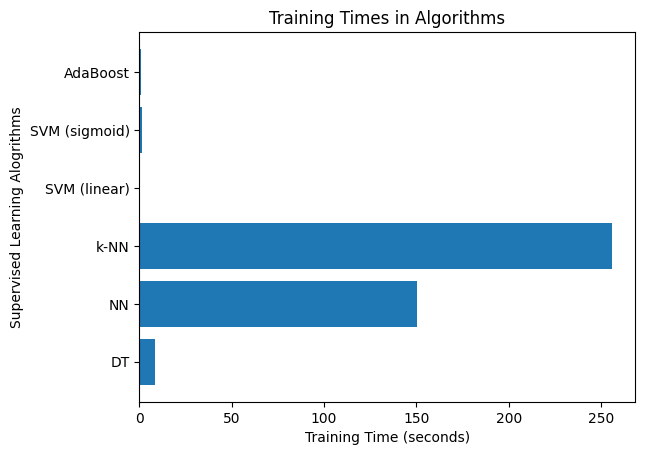

In [65]:
plt.figure()

plt.barh(y_ticks, training_time)
plt.gca().set_yticks(y_ticks)
plt.gca().set_yticklabels(supervised_ml_algorithms)

plt.ylabel('Supervised Learning Alogrithms')
plt.xlabel('Training Time (seconds)')

plt.title('Training Times in Algorithms')
plt.show()

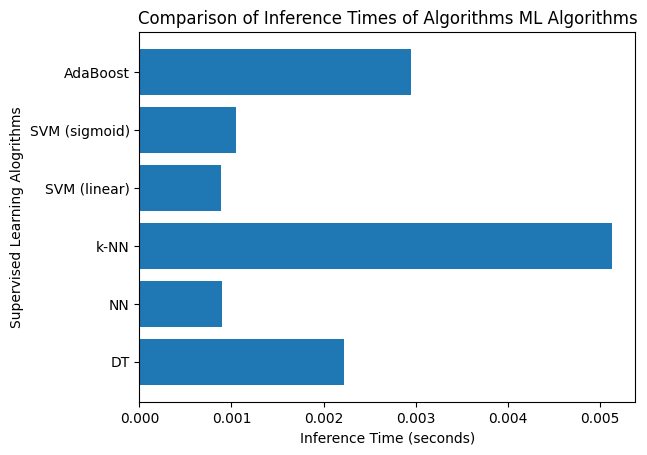

In [66]:


plt.figure()

plt.barh(y_ticks, prediction_duration)
plt.gca().set_yticks(y_ticks)
plt.gca().set_yticklabels(supervised_ml_algorithms)


plt.ylabel('Supervised Learning Alogrithms')
plt.xlabel('Inference Time (seconds)')

plt.title('Comparison of Inference Times of Algorithms ML Algorithms')
plt.show()



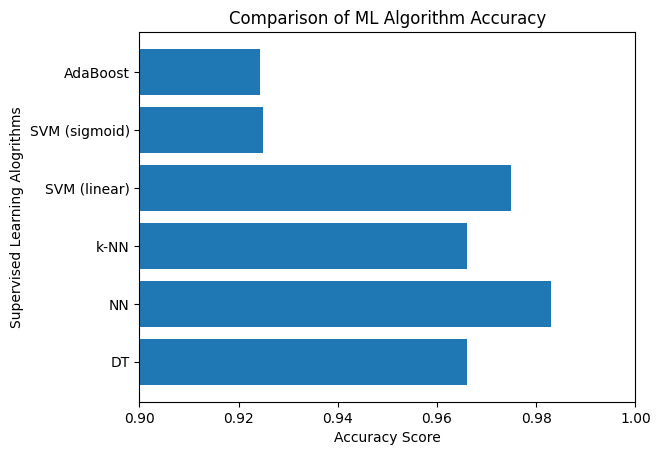

In [67]:


plt.figure()
plt.barh(y_ticks, accuracy)

plt.gca().set_yticks(y_ticks)
plt.gca().set_yticklabels(supervised_ml_algorithms)

plt.gca().set_xlim(0.90, 1)

plt.ylabel('Supervised Learning Alogrithms')
plt.xlabel('Accuracy Score')

plt.title('Comparison of ML Algorithm Accuracy')
plt.show()



# Citations


In [ ]:
### Resources used for setup:

### Resources used for decision trees:
#https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
#https://www.datacamp.com/tutorial/decision-tree-classification-python

### Resource used for boosting:
# source https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
### Resource used for boosting:

### Resource used for SVM:
# Source https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html


### Resource used for K-NN:
# Source https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

### Resource used for NN:
# Source https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html